In [9]:
import pandas as pd

# 1. Cargar el dataset desde la carpeta data
df = pd.read_csv("../data/PRSA_Data_Aotizhongxin_20130301-20170228.csv")

# 2. Visualizar las primeras filas
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [10]:
print(df.columns)

Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')


In [11]:
import pandas as pd

# 3. Eliminar columna innecesaria
# (No aporta valor al modelo)
df = df.drop(columns=['No'])

In [12]:
# 4. Eliminar valores nulos
# (Evita errores en el modelo y asegura consistencia)
df = df.dropna()

In [13]:
# 5. Crear variable datetime
# (Unificamos año, mes, día y hora en una sola variable temporal)

df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

In [14]:
# 6. Ordenar por tiempo real (más importante que "No")
df = df.sort_values(by='datetime')

In [15]:
# 7. Reiniciar índice ordenado
df = df.reset_index(drop=True)

In [16]:
# 8. Seleccionar variables clave
# (Nos quedamos con lo relevante para predicción)

df = df[['datetime', 'PM2.5', 'TEMP', 'PRES', 'DEWP', 'WSPM', 'RAIN', 'station']]

In [17]:
# 9. Renombrar columnas
# (Facilita el uso en el modelo y mantiene consistencia)

df.rename(columns={
    'PM2.5': 'pm25',
    'TEMP': 'temperature',
    'PRES': 'pressure',
    'DEWP': 'dew_point',
    'WSPM': 'wind_speed',
    'RAIN': 'rain'
}, inplace=True)

In [18]:
# 10. Crear variables temporales
# (Captura patrones en el tiempo)

df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day

In [19]:
# 11. Crear variable de riesgo (MUY IMPORTANTE)
# (Convierte contaminación en niveles interpretables)

def risk_level(pm25):
    if pm25 > 150:
        return "high"
    elif pm25 > 75:
        return "medium"
    else:
        return "low"

df['risk'] = df['pm25'].apply(risk_level)

In [20]:
# 12. Ver dataset final limpio
df.head()

,datetime,pm25,temperature,pressure,dew_point,wind_speed,rain,station,hour,day,risk
0,2013-03-01 00:00:00,4.0,-0.7,1023.0,-18.8,4.4,0.0,Aotizhongxin,0,1,low
1,2013-03-01 01:00:00,8.0,-1.1,1023.2,-18.2,4.7,0.0,Aotizhongxin,1,1,low
2,2013-03-01 02:00:00,7.0,-1.1,1023.5,-18.2,5.6,0.0,Aotizhongxin,2,1,low
3,2013-03-01 03:00:00,6.0,-1.4,1024.5,-19.4,3.1,0.0,Aotizhongxin,3,1,low
4,2013-03-01 04:00:00,3.0,-2.0,1025.2,-19.5,2.0,0.0,Aotizhongxin,4,1,low


In [21]:
## 1. Importar librerías necesarias
# (Herramientas para modelado y evaluación)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [22]:
# 9. Crear nuevas variables (feature engineering)

# interacción clima
df['temp_wind'] = df['temperature'] * df['wind_speed']

# evitar división entre 0
df['humidity_proxy'] = df['dew_point'] / (df['temperature'] + 1e-5)

# hora pico
df['rush_hour'] = df['hour'].apply(lambda x: 1 if x in [7,8,9,18,19,20] else 0)

In [23]:
import numpy as np

# 10. Manejo de valores problemáticos

# reemplazar infinitos
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# eliminar filas con problemas
df = df.dropna()

In [24]:
# convertir variable categórica a numérica
df = pd.get_dummies(df, columns=['station'], drop_first=True)

In [25]:
# 2. Seleccionar variables (features) y objetivo (target)

# Variables que el modelo usará para aprender
# Variables SIN pm25
# 11. Variables del modelo

X = df.drop(columns=['risk', 'datetime', 'pm25'])
y = df['risk']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
# 4. Crear el modelo Random Forest
# (Modelo robusto para clasificación)

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=4,
    random_state=42,
    class_weight='balanced'
)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
# 5. Entrenar el modelo
# (Aquí el modelo aprende patrones en los datos)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_split=4, n_estimators=300, random_state=42)

In [30]:
# 6. Hacer predicciones
# (El modelo intenta clasificar nuevos datos)

from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        high       0.52      0.74      0.61       997
         low       0.85      0.71      0.77      3772
      medium       0.49      0.55      0.52      1594

    accuracy                           0.68      6363
   macro avg       0.62      0.67      0.64      6363
weighted avg       0.71      0.68      0.69      6363



In [31]:
# 1. Importar librerías necesarias
# (Para evaluar y visualizar el modelo)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [32]:
# 2. Crear matriz de confusión
# (Compara valores reales vs predicciones)

cm = confusion_matrix(y_test, y_pred)

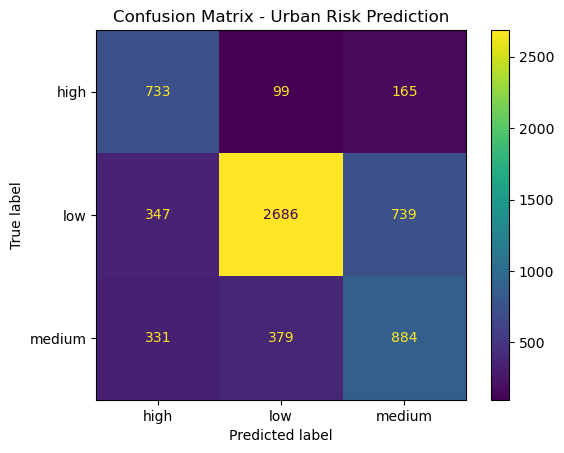

In [33]:
# 3. Visualizar matriz de confusión
# (Gráfica clara para análisis en el paper)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot(values_format='d')
plt.title("Confusion Matrix - Urban Risk Prediction")
plt.show()

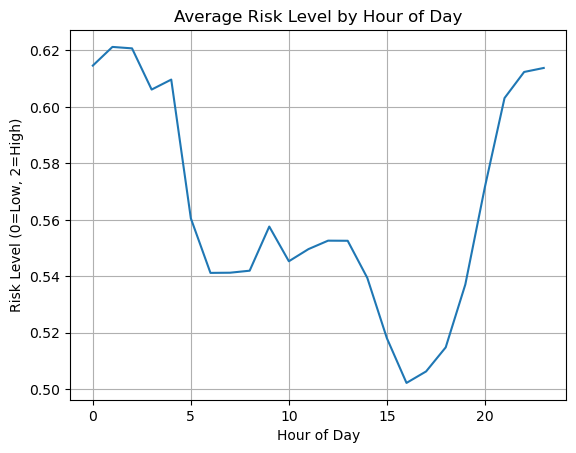

In [34]:
import matplotlib.pyplot as plt

# 1. Convertir riesgo a número para graficar
# (low=0, medium=1, high=2)
risk_map = {'low': 0, 'medium': 1, 'high': 2}
df['risk_num'] = df['risk'].map(risk_map)

# 2. Agrupar por hora
# (promedio de riesgo por cada hora del día)
hourly_risk = df.groupby('hour')['risk_num'].mean()

# 3. Graficar
plt.figure()
plt.plot(hourly_risk.index, hourly_risk.values)
plt.title("Average Risk Level by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Risk Level (0=Low, 2=High)")
plt.grid()

plt.show()

In [36]:
import pandas as pd
import numpy as np

# ===========================
# 1. Cargar dataset original de Beijing
# ===========================
df = pd.read_csv("../data/PRSA_Data_Aotizhongxin_20130301-20170228.csv")

# ===========================
# 2. Crear columna datetime
# ===========================
df['datetime'] = pd.to_datetime(df[['year','month','day','hour']])

# ===========================
# 3. Ordenar por datetime
# ===========================
df = df.sort_values(by='datetime').reset_index(drop=True)

# ===========================
# 4. Manejar valores problemáticos
# ===========================
# Reemplazar infinitos por NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Eliminar filas con NaN
df = df.dropna()

# ===========================
# 5. Crear variables derivadas importantes
# ===========================
# Interacción clima: temp * wind
df['temp_wind'] = df['TEMP'] * df['WSPM']

# Humedad aproximada
df['humidity_proxy'] = df['DEWP'] / (df['TEMP'] + 1e-5)

# Hora pico
df['rush_hour'] = df['hour'].apply(lambda x: 1 if x in [7,8,9,18,19,20] else 0)

# ===========================
# 6. Convertir estación a variable dummy (si hay varias estaciones)
# ===========================
if 'station' in df.columns:
    df = pd.get_dummies(df, columns=['station'], drop_first=True)

# ===========================
# 7. Mapear niveles de riesgo (ejemplo PM2.5)
# ===========================
# Definimos riesgo basado en PM2.5
def pm25_risk(value):
    if value <= 50:
        return 'Low'
    elif value <= 100:
        return 'Medium'
    else:
        return 'High'

df['risk'] = df['PM2.5'].apply(pm25_risk)

# ===========================
# 8. Guardar dataset limpio
# ===========================
df.to_csv("../data/clean_data.csv", index=False)
print("clean_data.csv generado correctamente con", len(df), "filas.")

clean_data.csv generado correctamente con 31815 filas.


In [37]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# Supongamos que ya entrenaste tu modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Guardar el modelo
joblib.dump(model, "../data/model.pkl")

# Guardar columnas usadas (muy importante para el test)
joblib.dump(X_train.columns, "../data/X_columns.pkl")

['../data/X_columns.pkl']